# CNM + Primordial + Experimental (RHIC) Step-by-Step

Notebook workflow for d+Au 200 GeV in the same staged style as CNM production.

Defaults:
- RHIC baseline CNM uses **nuclear absorption ON**
- Colors are consistent with LHC notebook
- If RHIC primordial inputs are unavailable, notebook falls back cleanly to CNM(+exp) only


## Step 0: Setup


In [1]:
import sys
from pathlib import Path
import pandas as pd

project = Path.cwd()
if not (project / 'cnm_primordial_notebooks').exists():
    project = project.parent

sys.path.insert(0, str(project / 'cnm_primordial_notebooks'))
import cnm_primordial_publication_lib as pub

pub.configure_matplotlib()
print('Project:', project)


Project: /home/sawin/Desktop/Charmonia/charmonia_combined_analysis


## Step 1: Analysis Configuration (edit here)


In [2]:
SYSTEM = 'RHIC'
ENERGY = '200'
FORMATION = 'radius'  # kept for output bookkeeping and future primordial use

STATES = ['jpsi_1S', 'psi_2S']

# RHIC default baseline: absorption ON
USE_ABSORPTION_PRIMARY = True
SHOW_ALT_CNM = True


# RHIC nuclear-absorption state dependence (singlet-ordering motivated defaults; editable)
USE_STATE_DEPENDENT_ABS = True
RHIC_ABS_SIGMA_BY_STATE = {
    'jpsi_1S': {'central': 4.2, 'low': 3.0, 'high': 5.5},
    'chicJ_1P': {'central': 5.3, 'low': 4.0, 'high': 6.8},
    'psi_2S': {'central': 6.4, 'low': 5.0, 'high': 7.7},
}


INCLUDE_PRIMORDIAL = True   # auto-disabled below if primordial is unavailable
INCLUDE_COMBINED = True
SHOW_CNM_COMPONENTS = False
BAND_MODE = 'quadrature'
INCLUDE_EXPERIMENT = True


# Manual plot-range / legend controls (publication tuning)
CENT_XLIM = (0.0, 100.0)  # keep theory axis to 100%
CENT_YLIM = (0.0, 1.6)
Y_XLIM = None
Y_YLIM = (0.0, 2.5)
PT_XLIM = None
PT_YLIM = (0.0, 2.5)

CENT_LEGEND_LOC = 'lower center'
CENT_LEGEND_NCOL = 2

Y_LEGEND_LOCATION = 'bottom'   # 'top' or 'bottom'
Y_LEGEND_REPEAT = False
Y_LEGEND_NCOL = 2
Y_LEGEND_BOLD = False

PT_NOTE_LOC_FIRST = 'lower right'


# Easy style knobs
THEORY_STYLE_OVERRIDES = {
    'prim_pert': {'color': 'tab:red', 'ls': '--', 'label': 'TAMU-P'},
    'prim_npwlc': {'label': 'TAMU-NP'},
    'comb_pert': {'color': 'tab:red', 'ls': '-', 'label': r'CNM$\times$TAMU-P'},
    'comb_npwlc': {'label': r'CNM$\times$TAMU-NP'},
}
COMPONENT_STYLE_OVERRIDES = {
    # keep component palette distinct from Pert red/NPWLC green
    'eloss': {'color': '#8C564B'},
}
TEXT_STYLE_OVERRIDES = {
    'system_color': '#0B3D91',
    'state_color': 'black',
    'tag_color': '#1F77B4',
    'system_fontsize': 11.0,
    'state_fontsize': 11.0,
    'tag_fontsize': 10.0,
    'note_fontsize': 9.3,
}

LEGEND_FONT_SIZE = 8.2
PT_LEGEND_SPLIT = True

PT_MASTERGRID = True
PT_MASTERGRID_XLIM = (0.0, 10.0)
PT_MASTERGRID_YLIM = PT_YLIM
PT_MASTERGRID_LEGEND_SPLIT = True



SAVE_PDF = True
SAVE_PNG = False

out_root = project / 'outputs' / 'combined_cnm_primordial_experimental' / 'RHIC_200GeV' / FORMATION / 'step_by_step'
out_root.mkdir(parents=True, exist_ok=True)
out_root


PosixPath('/home/sawin/Desktop/Charmonia/charmonia_combined_analysis/outputs/combined_cnm_primordial_experimental/RHIC_200GeV/radius/step_by_step')

## Step 2: Build System Setup


In [3]:
pub.apply_style_overrides(
    theory_style_overrides=THEORY_STYLE_OVERRIDES,
    component_style_overrides=COMPONENT_STYLE_OVERRIDES,
    text_style_overrides=TEXT_STYLE_OVERRIDES,
)

setup = pub.get_system_setup(SYSTEM, ENERGY)
setup


SystemSetup(system='RHIC', energy='200', cent_bins=[(0, 20), (20, 40), (40, 60), (60, 100)], y_windows={'backward': (-2.2, -1.2), 'central': (-0.35, 0.35), 'forward': (1.2, 2.2)}, y_edges=array([-3.5, -3. , -2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,
        2. ,  2.5,  3. ]), pt_edges=array([ 0. ,  2.5,  5. ,  7.5, 10. ]), pt_range_integrated=(0.0, 5.0), r_label='$R_{dA}$')

## Step 3: Try Primordial Build (safe fallback if unavailable)


In [4]:
prim = pub.build_primordial_products(setup, FORMATION, STATES)
print('Primordial available:', prim.available)
print('Reason:', prim.reason)

if not prim.available:
    INCLUDE_PRIMORDIAL = False
    INCLUDE_COMBINED = False
    print('[info] RHIC run will proceed with CNM-only + experimental overlays.')


Primordial available: False
Reason: No RHIC primordial input paths are configured in this repository.
[info] RHIC run will proceed with CNM-only + experimental overlays.


## Step 4: Build CNM Products Per State


In [5]:
cnm_by_state = {}
for st in STATES:
    print(f'Building CNM for {st} ...')
    cnm_by_state[st] = pub.build_cnm_state_products(
        setup,
        st,
        use_absorption_primary=USE_ABSORPTION_PRIMARY,
        include_cnm_components=SHOW_CNM_COMPONENTS,
        abs_sigma_map=(RHIC_ABS_SIGMA_BY_STATE if USE_STATE_DEPENDENT_ABS else None),
    )

pub.summarize_products(cnm_by_state, prim)


Building CNM for jpsi_1S ...
Building CNM for psi_2S ...


,state,primary_variant,n_y_bins,n_pt_bins,n_cent_bins,primordial_available
0,jpsi_1S,abs,13,4,4,False
1,psi_2S,abs,13,4,4,False


## Step 5: Plot Family A - $R_{dA}$ vs Centrality


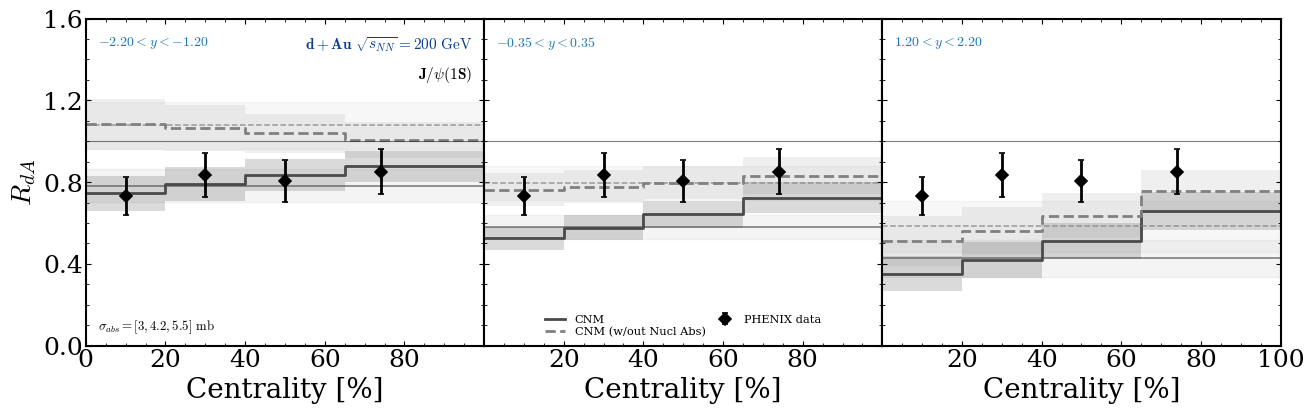

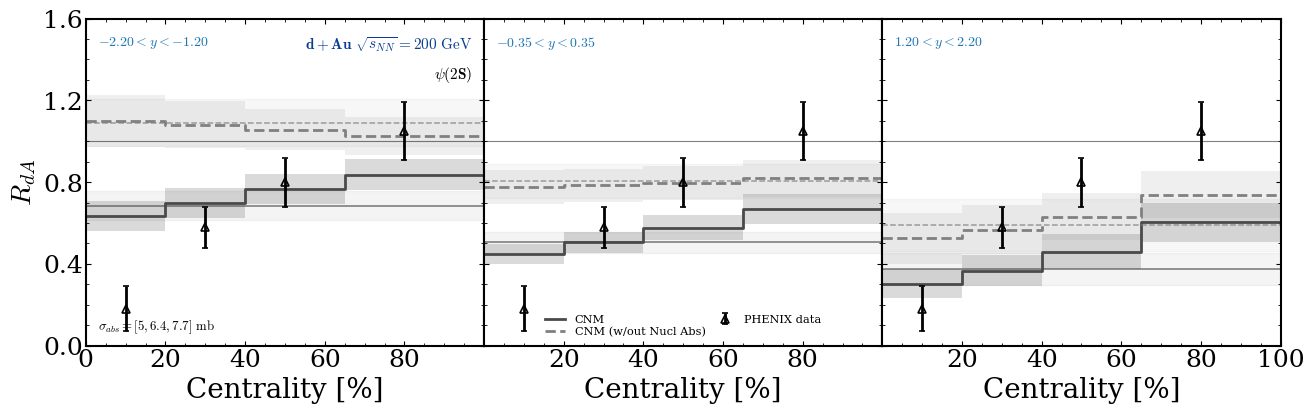

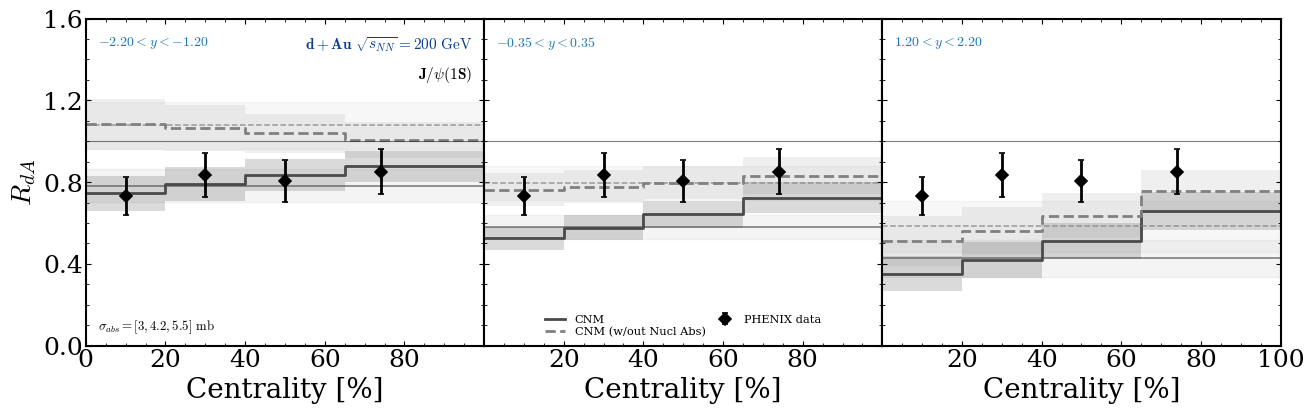

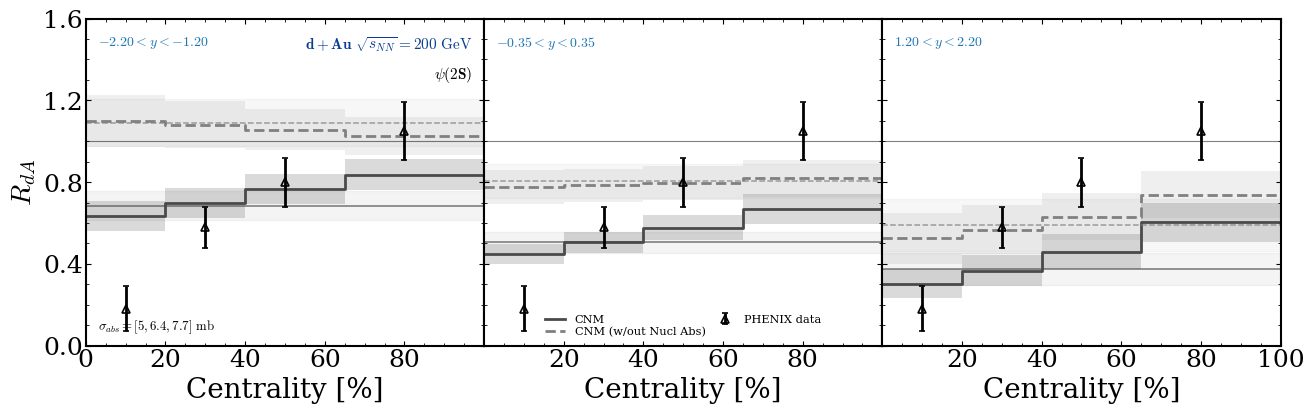

In [6]:
rows_cent = []
for st in STATES:
    fig, rows = pub.plot_state_vs_centrality(
        setup=setup,
        formation=FORMATION,
        state=st,
        cnm=cnm_by_state[st],
        prim=prim,
        include_primordial=INCLUDE_PRIMORDIAL,
        include_combined=INCLUDE_COMBINED,
        show_cnm_components=SHOW_CNM_COMPONENTS,
        show_alt_cnm=SHOW_ALT_CNM,
        band_mode=BAND_MODE,
        include_experiment=INCLUDE_EXPERIMENT,
        xlim=CENT_XLIM,
        ylim=CENT_YLIM,
        legend_loc=CENT_LEGEND_LOC,
        legend_ncol=CENT_LEGEND_NCOL,
        legend_fontsize=LEGEND_FONT_SIZE,
        text_style=TEXT_STYLE_OVERRIDES,
    )
    pub.save_figure(fig, out_root / f'RdA_vs_centrality_{st}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
    rows_cent.extend(rows)
    display(fig)


## Step 6: Plot Family B - $R_{dA}$ vs $y$


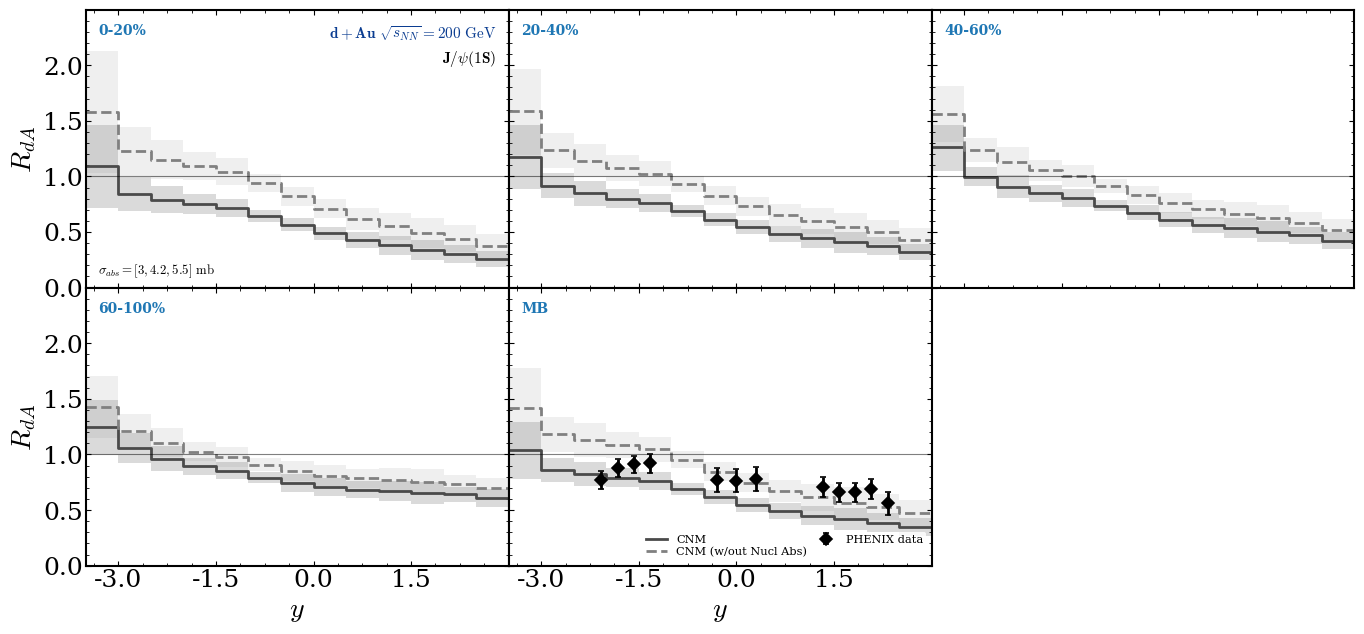

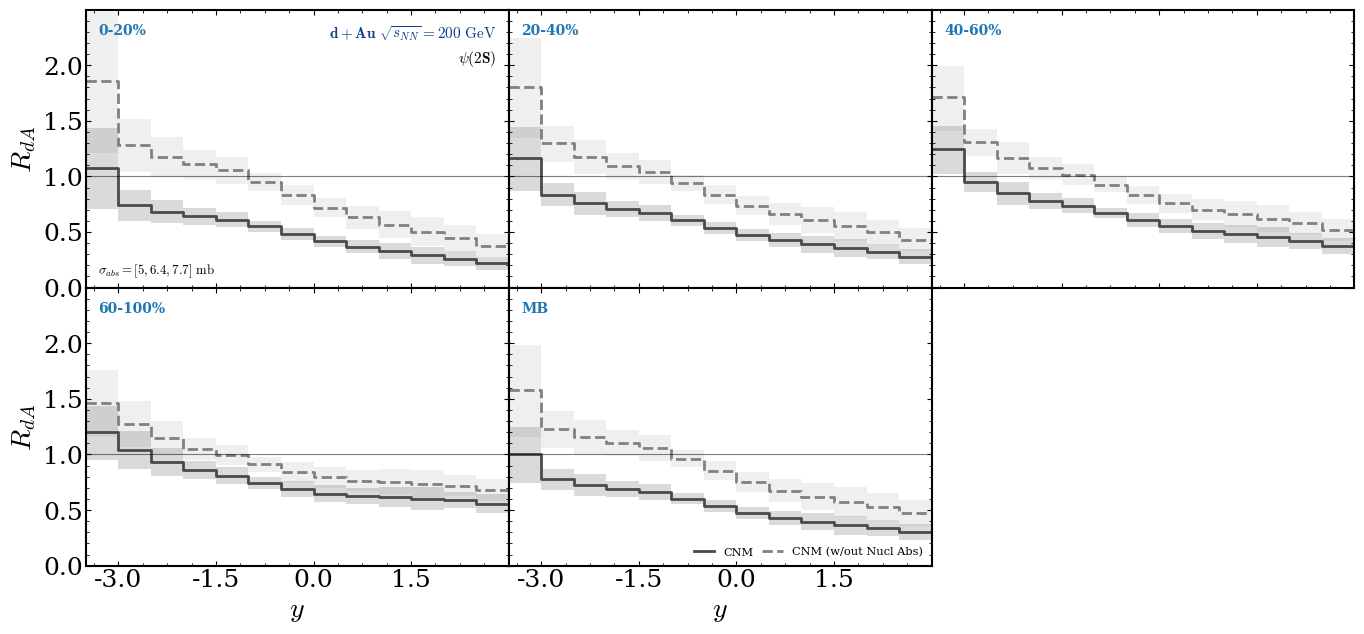

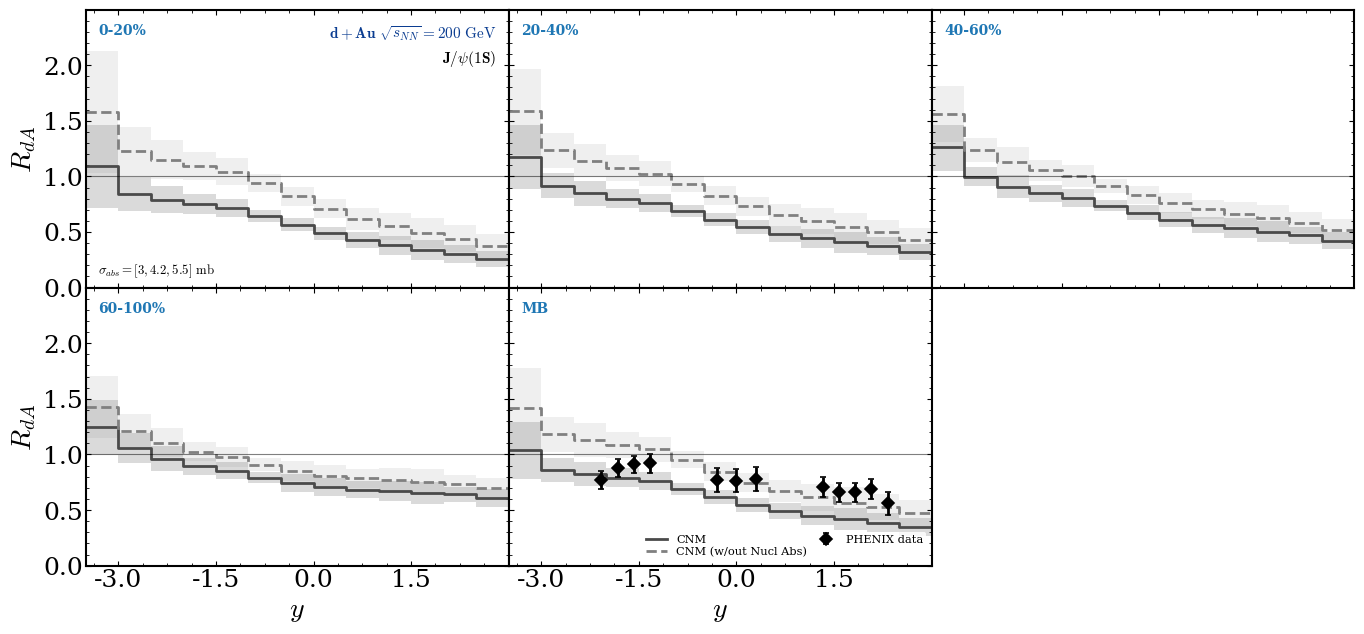

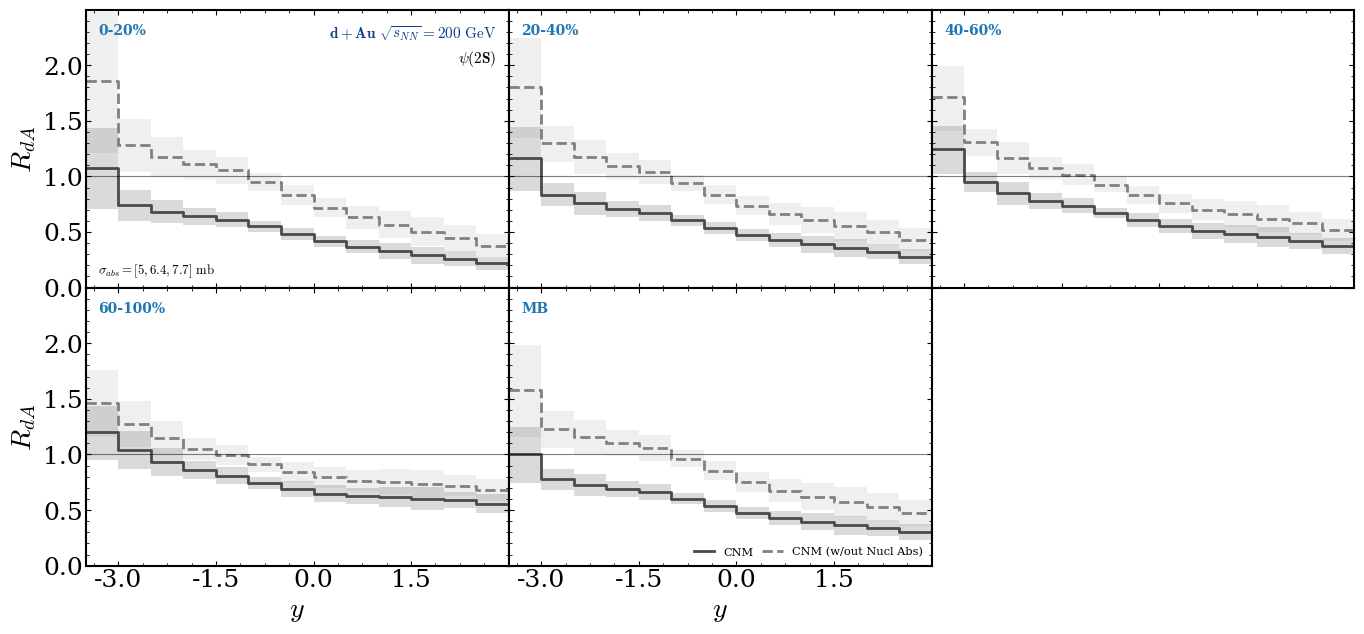

In [7]:
rows_y = []
for st in STATES:
    fig, rows = pub.plot_state_vs_y(
        setup=setup,
        formation=FORMATION,
        state=st,
        cnm=cnm_by_state[st],
        prim=prim,
        include_primordial=INCLUDE_PRIMORDIAL,
        include_combined=INCLUDE_COMBINED,
        show_cnm_components=SHOW_CNM_COMPONENTS,
        show_alt_cnm=SHOW_ALT_CNM,
        band_mode=BAND_MODE,
        include_experiment=INCLUDE_EXPERIMENT,
        xlim=Y_XLIM,
        ylim=Y_YLIM,
        legend_location=Y_LEGEND_LOCATION,
        legend_repeat=Y_LEGEND_REPEAT,
        legend_ncol=Y_LEGEND_NCOL,
        legend_bold=Y_LEGEND_BOLD,
        legend_fontsize=LEGEND_FONT_SIZE,
        text_style=TEXT_STYLE_OVERRIDES,
    )
    pub.save_figure(fig, out_root / f'RdA_vs_y_{st}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
    rows_y.extend(rows)
    display(fig)


## Step 7: Plot Family C - $R_{dA}$ vs $p_T$


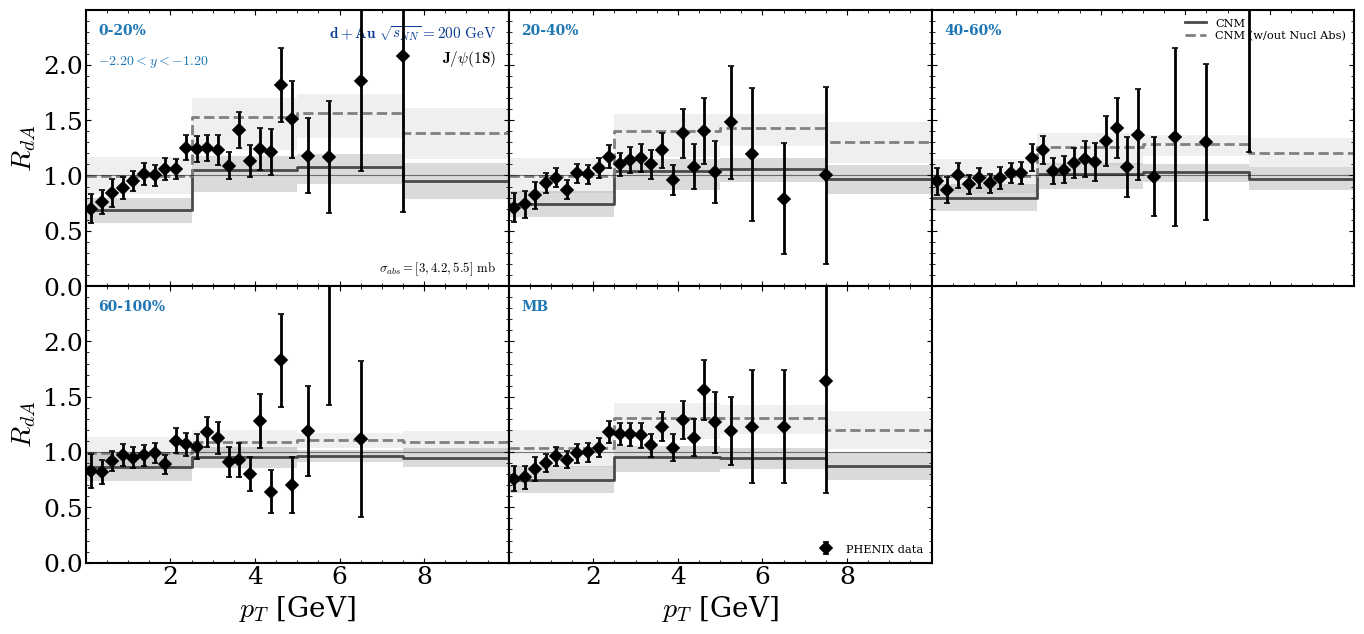

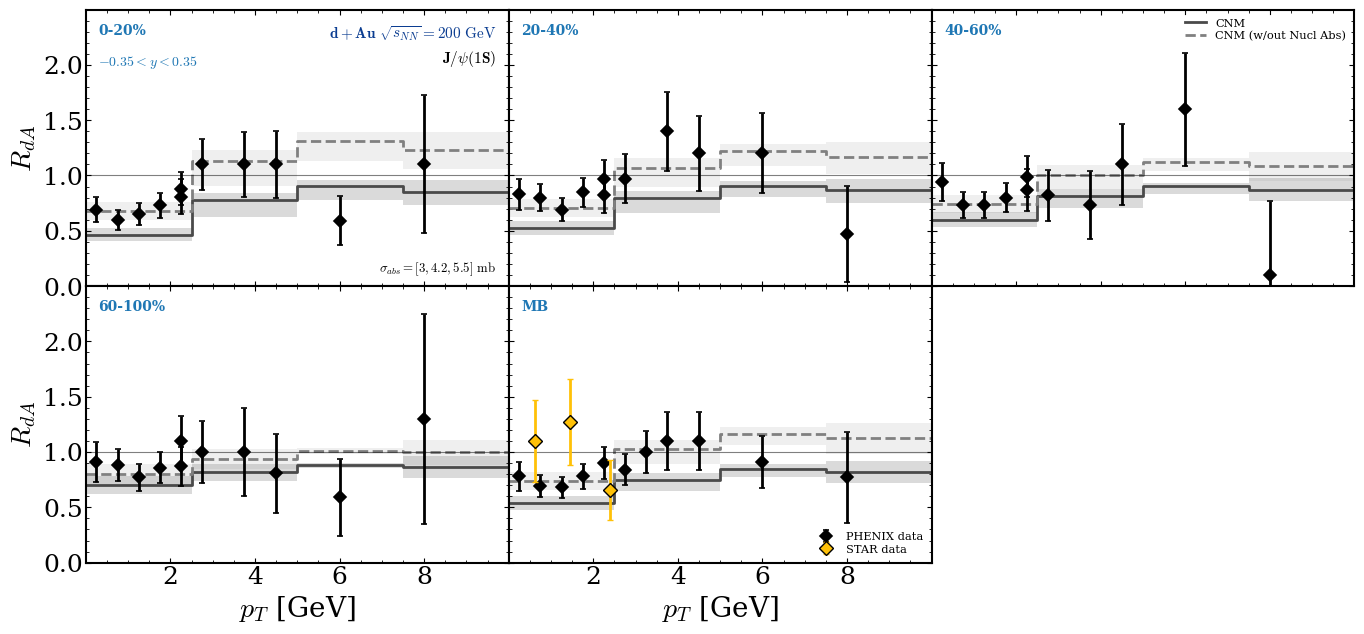

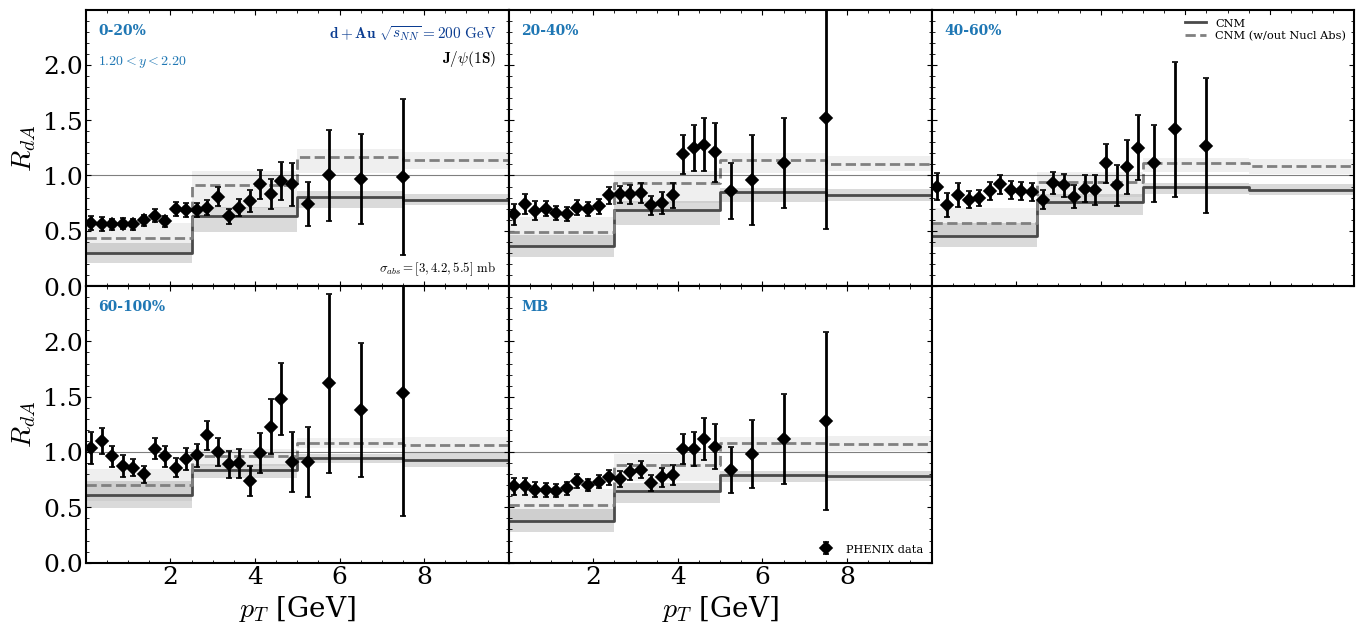

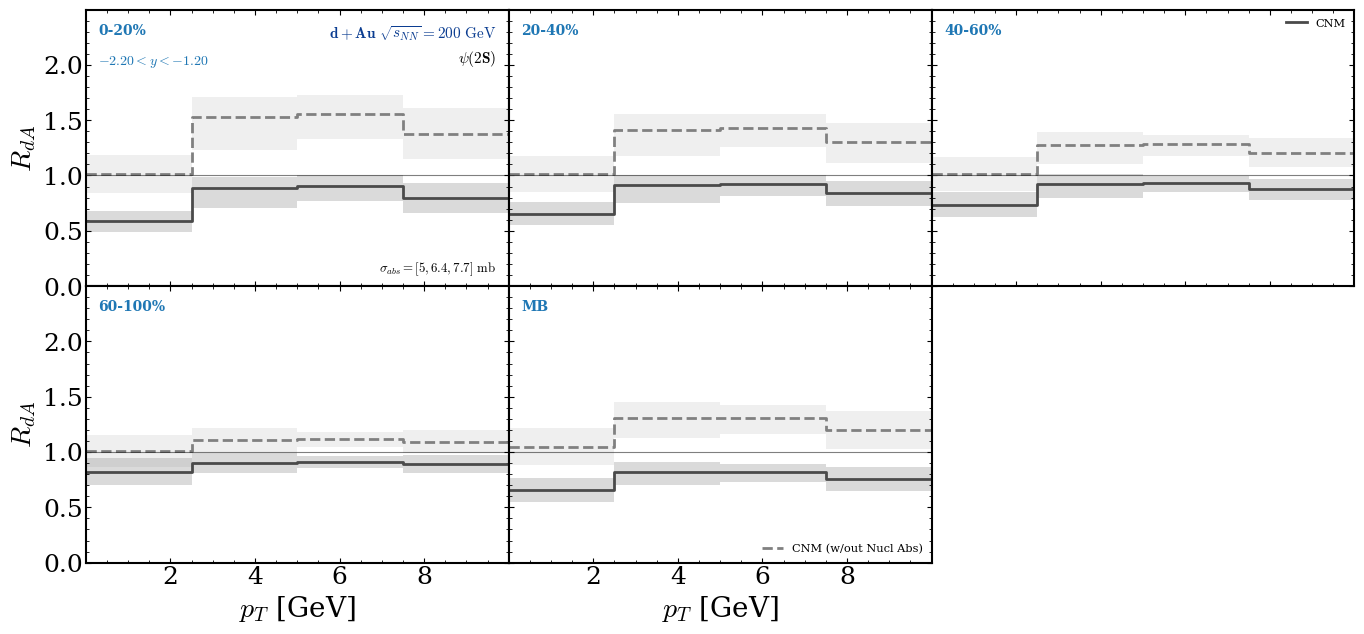

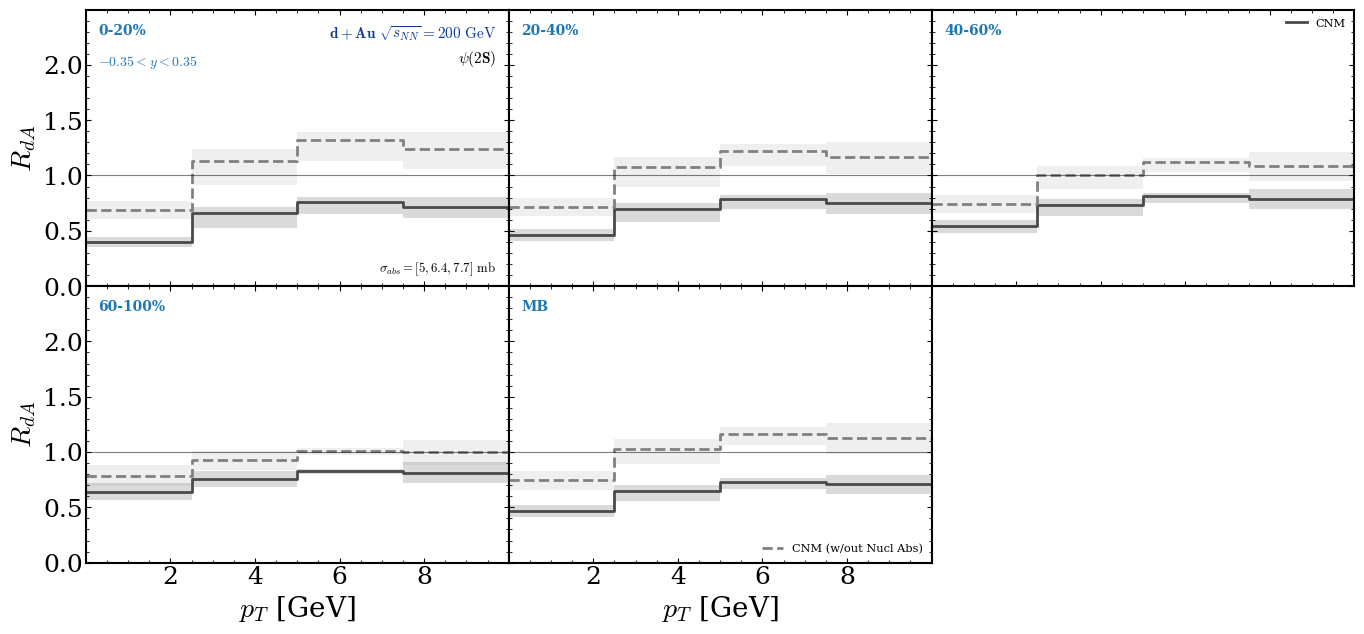

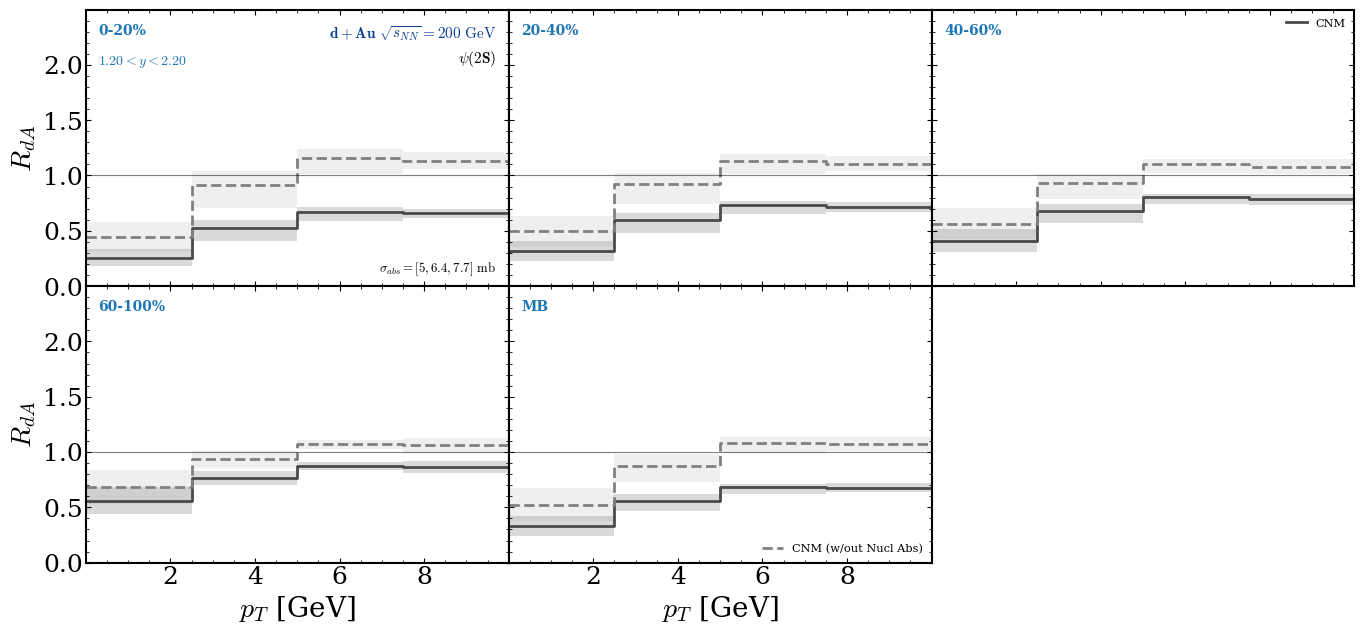

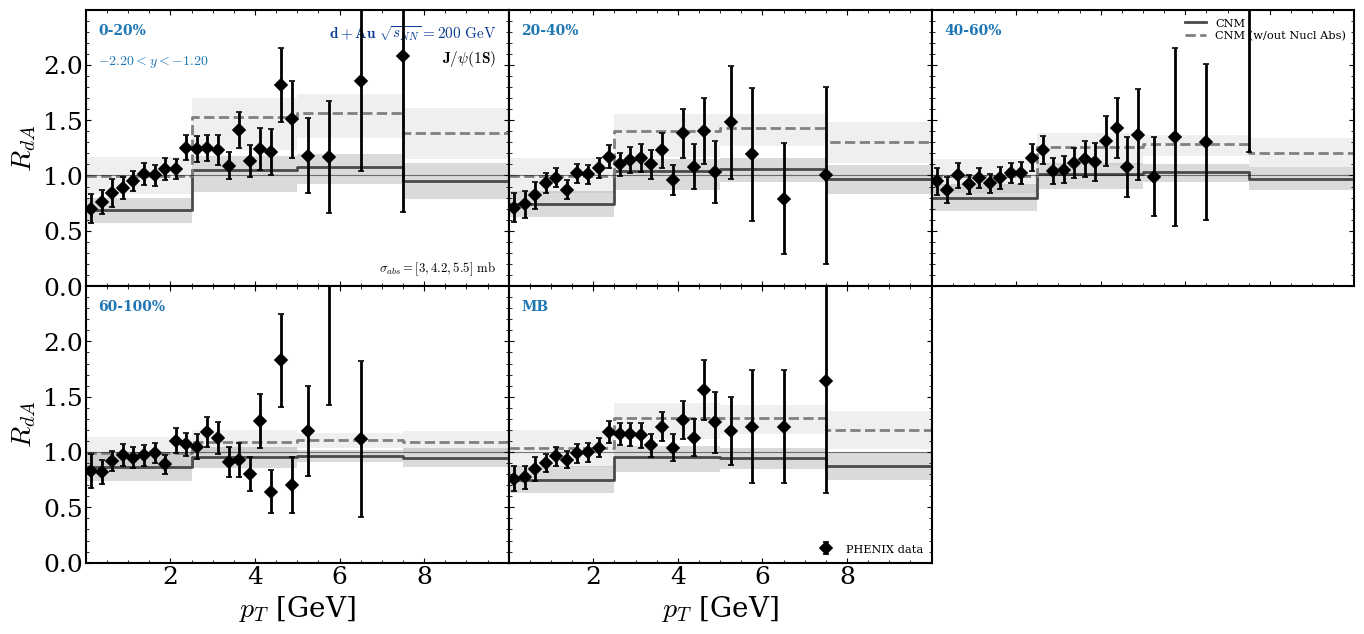

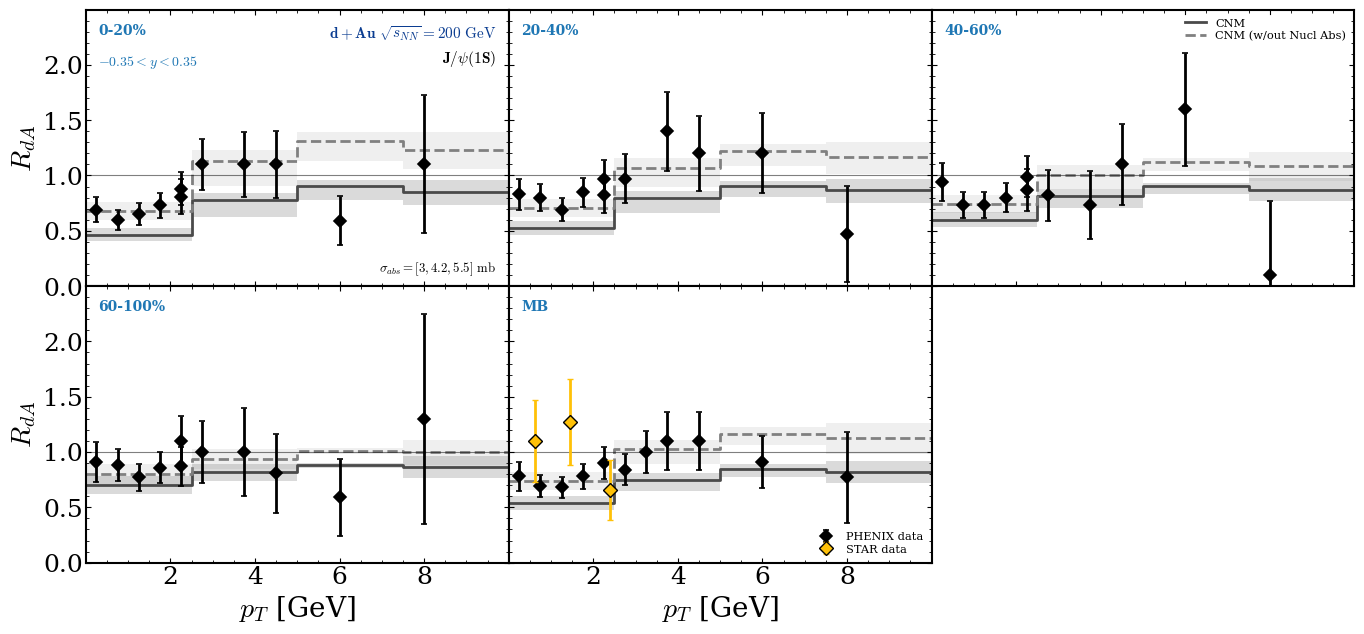

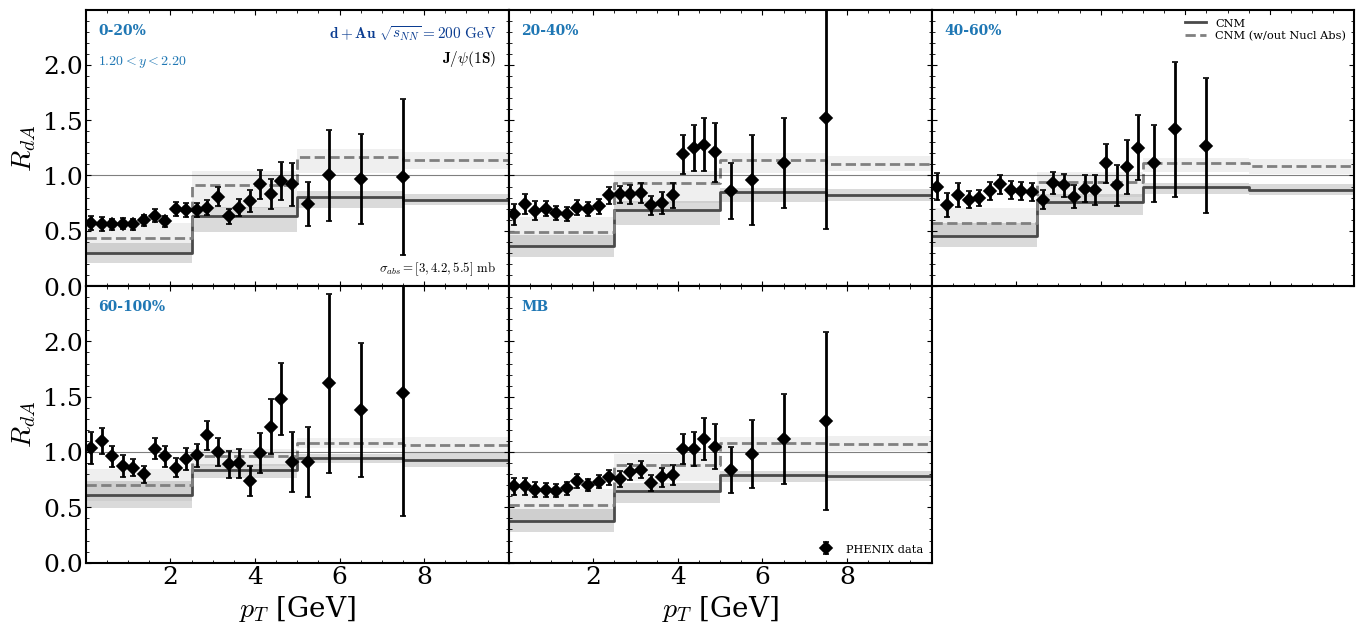

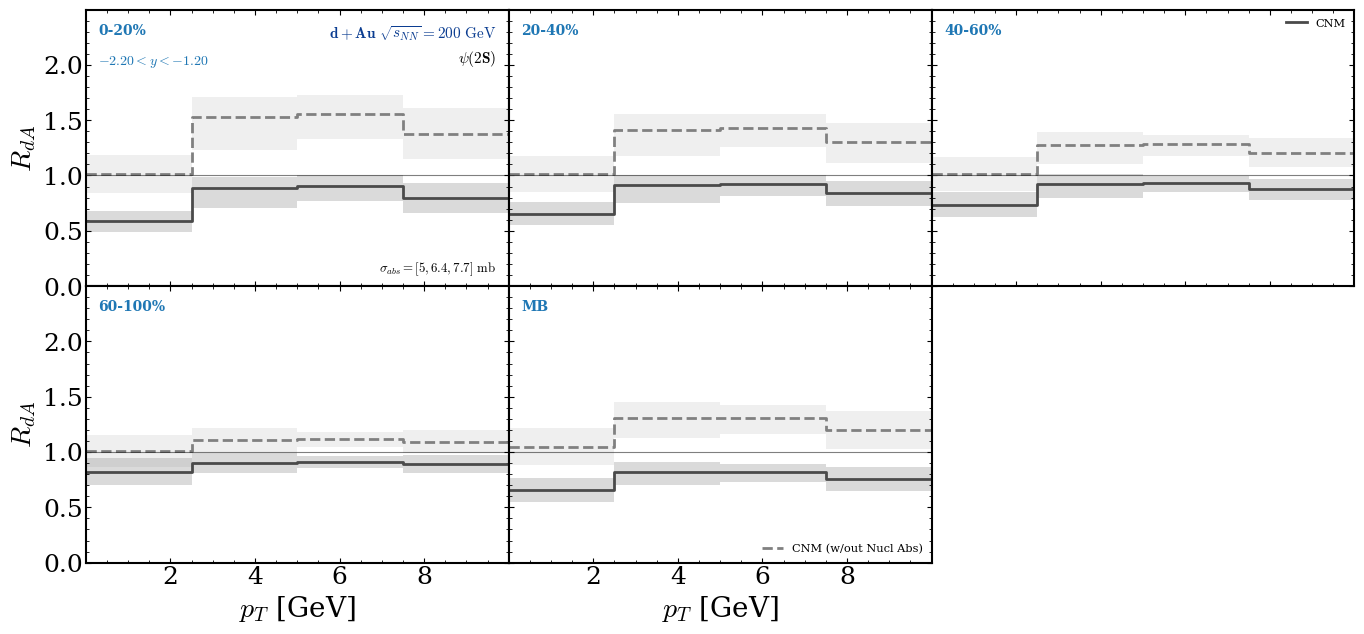

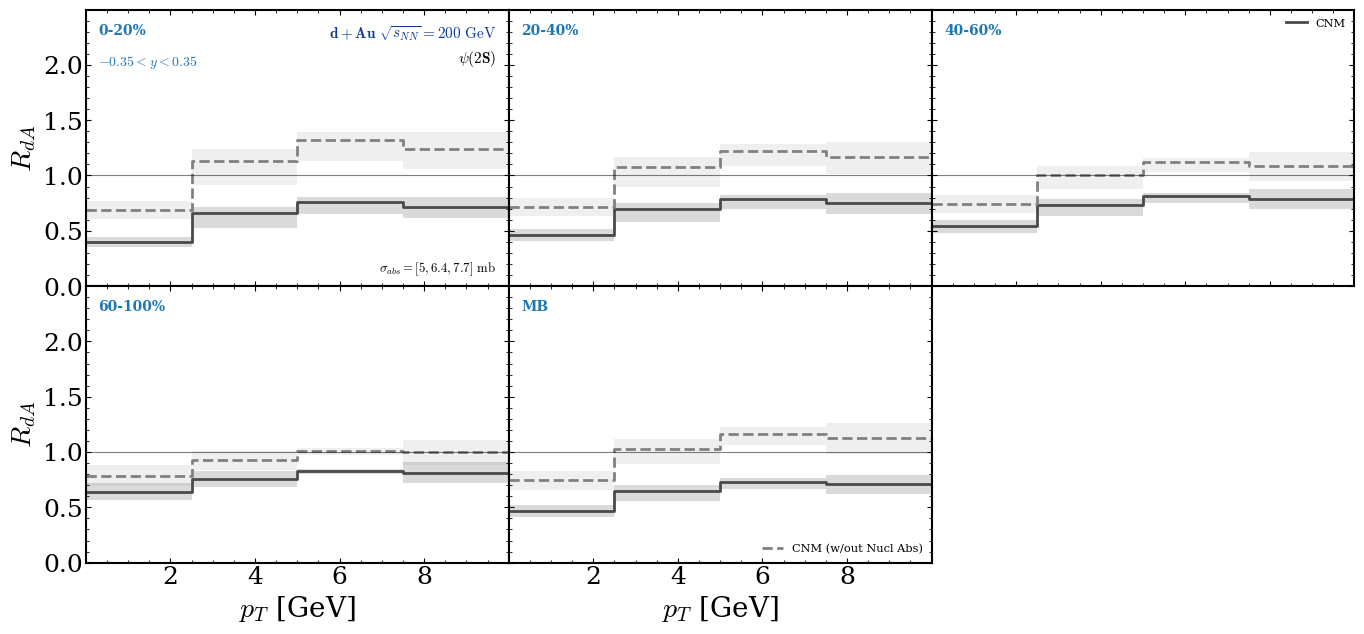

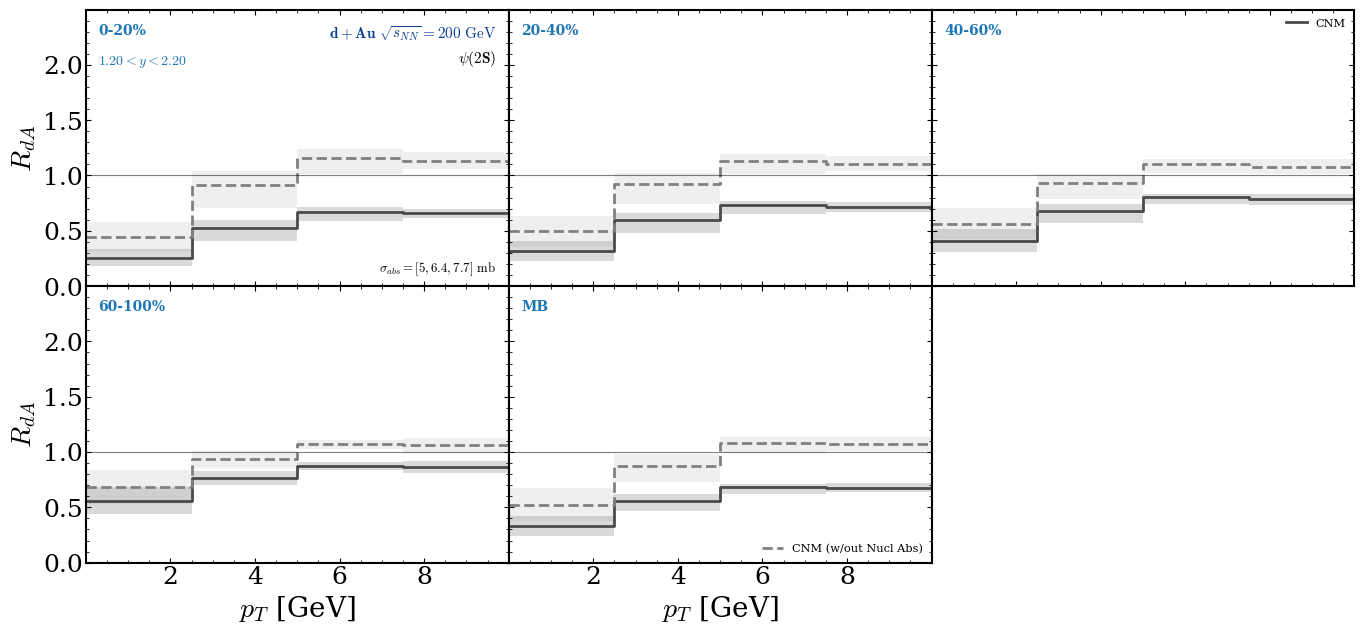

In [8]:
rows_pt = []
for st in STATES:
    by_y = pub.plot_state_vs_pt(
        setup=setup,
        formation=FORMATION,
        state=st,
        cnm=cnm_by_state[st],
        prim=prim,
        include_primordial=INCLUDE_PRIMORDIAL,
        include_combined=INCLUDE_COMBINED,
        show_cnm_components=SHOW_CNM_COMPONENTS,
        show_alt_cnm=SHOW_ALT_CNM,
        band_mode=BAND_MODE,
        include_experiment=INCLUDE_EXPERIMENT,
        xlim=(0,10),
        ylim=PT_YLIM,
        note_loc_first=PT_NOTE_LOC_FIRST,
        legend_split=PT_LEGEND_SPLIT,
        legend_fontsize=LEGEND_FONT_SIZE,
        legend_bold=False,
        text_style=TEXT_STYLE_OVERRIDES,
    )
    for yname, (fig, rows) in by_y.items():
        pub.save_figure(fig, out_root / f'RdA_vs_pT_{st}_{yname}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
        rows_pt.extend(rows)
        display(fig)


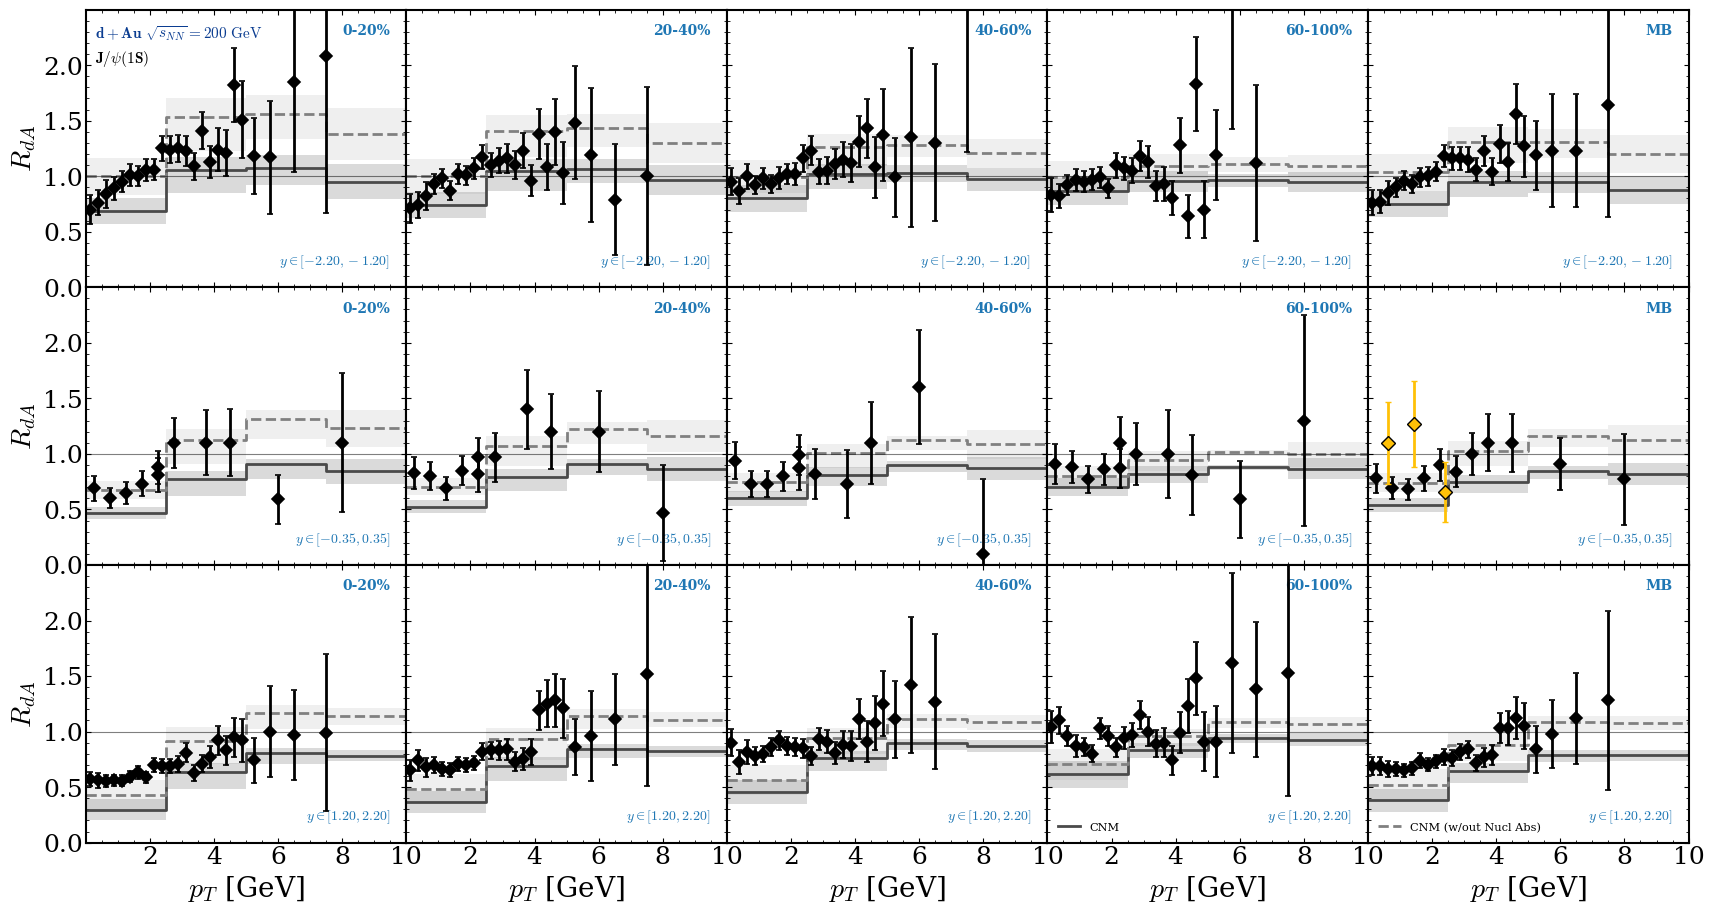

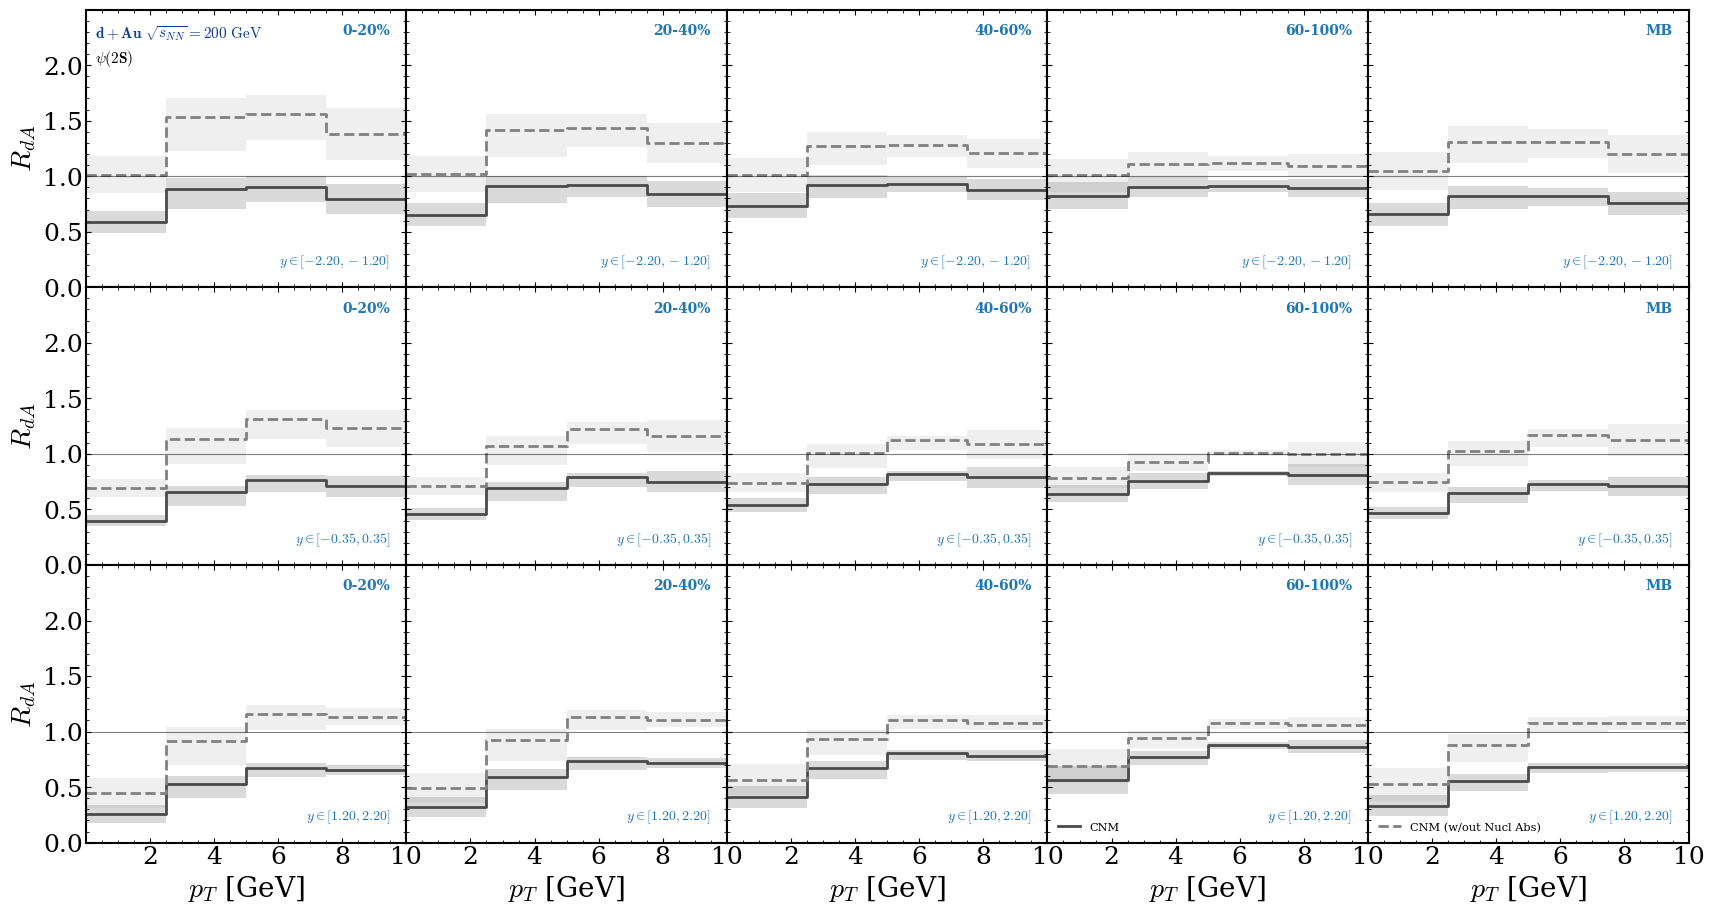

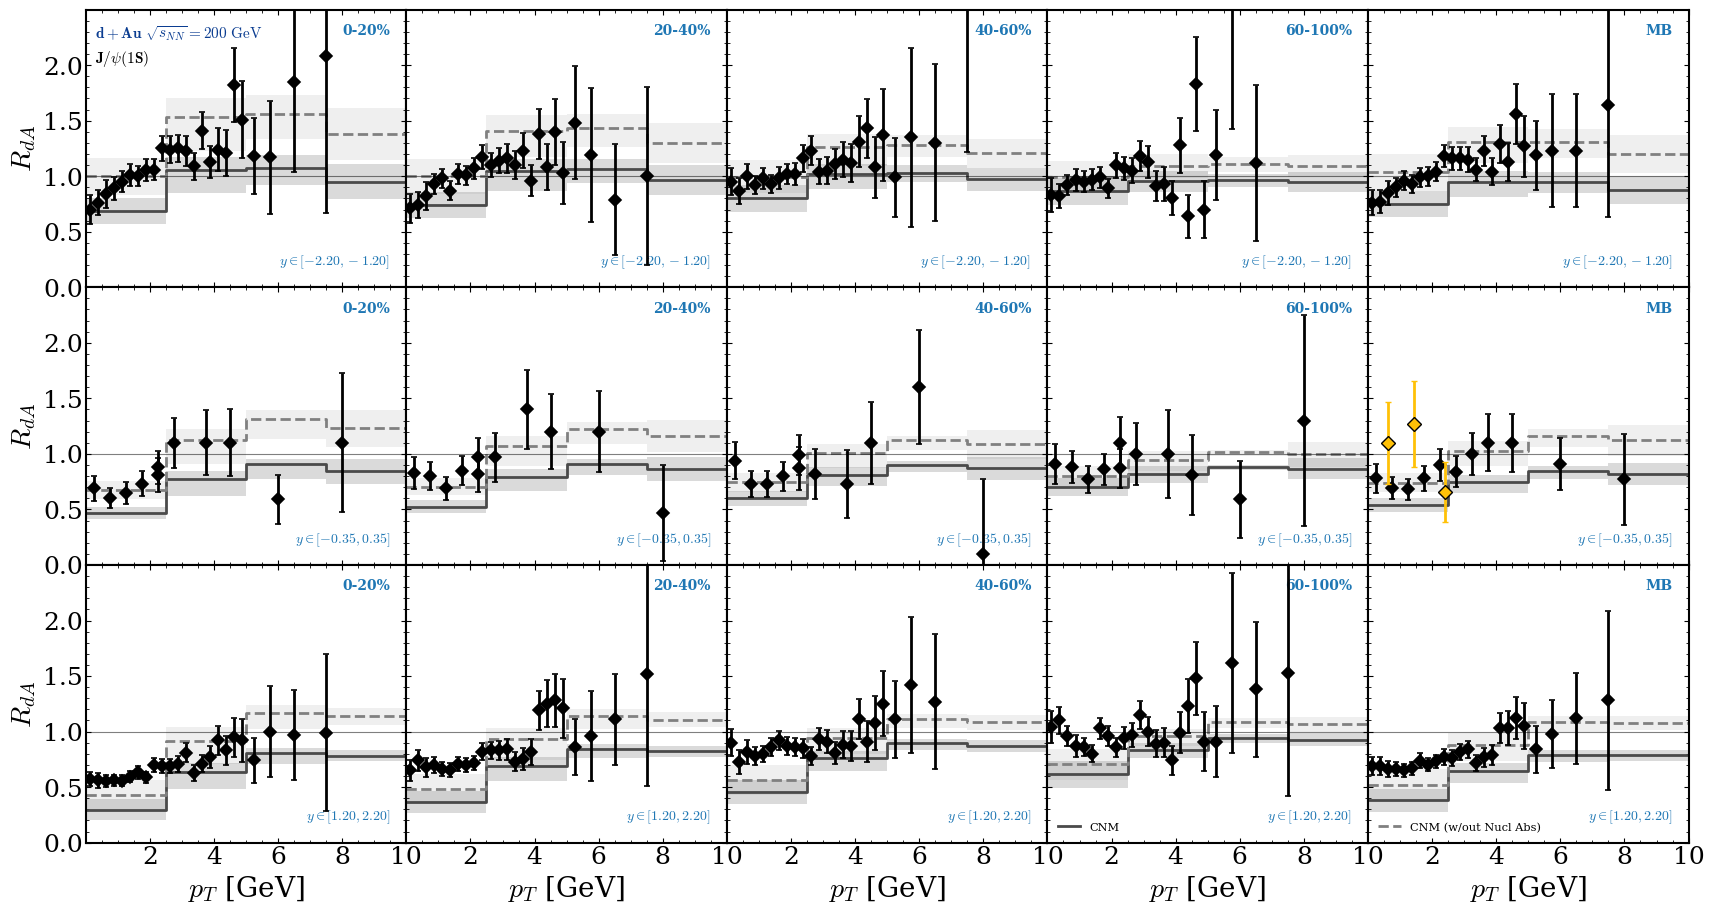

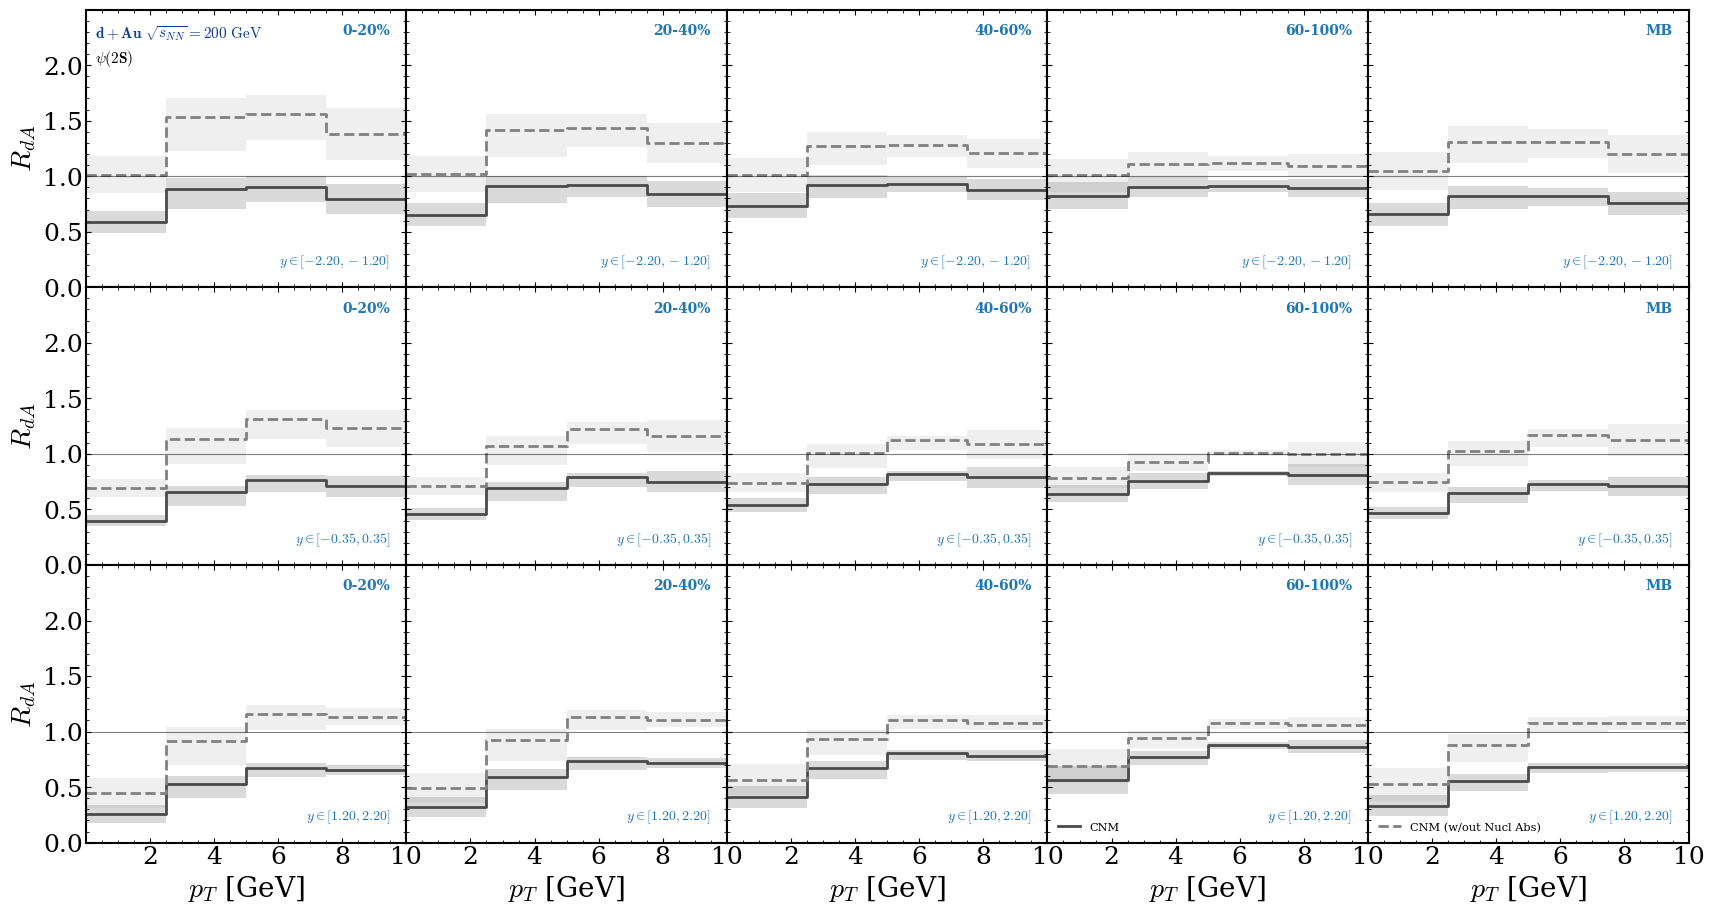

In [9]:

# Master grid (rapidity x centrality)
if PT_MASTERGRID:
    for st in STATES:
        fig, rows = pub.plot_state_vs_pt_mastergrid(
            setup=setup,
            formation=FORMATION,
            state=st,
            cnm=cnm_by_state[st],
            prim=prim,
            include_primordial=INCLUDE_PRIMORDIAL,
            include_combined=INCLUDE_COMBINED,
            show_cnm_components=SHOW_CNM_COMPONENTS,
            show_alt_cnm=SHOW_ALT_CNM,
            band_mode=BAND_MODE,
            include_experiment=INCLUDE_EXPERIMENT,
            xlim=PT_MASTERGRID_XLIM,
            ylim=PT_MASTERGRID_YLIM,
            note_loc_first=PT_NOTE_LOC_FIRST,
            legend_split=PT_MASTERGRID_LEGEND_SPLIT,
            legend_fontsize=LEGEND_FONT_SIZE,
            legend_bold=False,
            text_style=TEXT_STYLE_OVERRIDES,
        )
        pub.save_figure(fig, out_root / f'RdA_vs_pT_MasterGrid_{st}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
        rows_pt.extend(rows)
        display(fig)


## Step 8: Export Consolidated CSV + Quick Output Check


In [10]:
rows_all = rows_cent + rows_y + rows_pt
csv_path = out_root / f'combined_curves_RHIC_200GeV_{FORMATION}.csv'
pub.save_rows_csv(rows_all, csv_path)
print('Saved CSV:', csv_path)

files = sorted([p.name for p in out_root.glob('*')])
print('Generated files:', len(files))
for nm in files[:40]:
    print('-', nm)


Saved CSV: /home/sawin/Desktop/Charmonia/charmonia_combined_analysis/outputs/combined_cnm_primordial_experimental/RHIC_200GeV/radius/step_by_step/combined_curves_RHIC_200GeV_radius.csv
Generated files: 13
- RdA_vs_centrality_jpsi_1S.pdf
- RdA_vs_centrality_psi_2S.pdf
- RdA_vs_pT_MasterGrid_jpsi_1S.pdf
- RdA_vs_pT_MasterGrid_psi_2S.pdf
- RdA_vs_pT_jpsi_1S_backward.pdf
- RdA_vs_pT_jpsi_1S_central.pdf
- RdA_vs_pT_jpsi_1S_forward.pdf
- RdA_vs_pT_psi_2S_backward.pdf
- RdA_vs_pT_psi_2S_central.pdf
- RdA_vs_pT_psi_2S_forward.pdf
- RdA_vs_y_jpsi_1S.pdf
- RdA_vs_y_psi_2S.pdf
- combined_curves_RHIC_200GeV_radius.csv
